In [1]:
from sklearn.datasets import make_circles, make_blobs
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from matplotlib.colors import ListedColormap
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


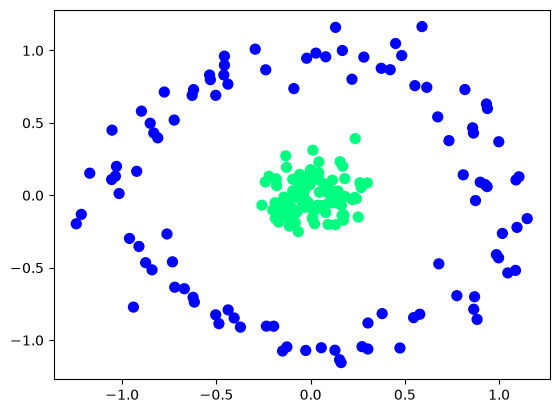

In [2]:
X, y = make_circles(n_samples= 200, factor= 0.1, noise = 0.1)
plt.scatter(X[:,0], X[:,1],c = y, s = 50, cmap = 'winter')

In [3]:
zero_one_colourmap = ListedColormap(('blue', 'red'))
def plot_decision_boundary(X, y, clf):
    X_set, y_set = X, y
    X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 1, 
                                 stop = X_set[:, 0].max() + 1, 
                                 step = 0.01),
                       np.arange(start = X_set[:, 1].min() - 1, 
                                 stop = X_set[:, 1].max() + 1, 
                                 step = 0.01))
  
    plt.contourf(X1, X2, clf.predict(np.array([X1.ravel(), 
                                             X2.ravel()]).T).reshape(X1.shape),
               alpha = 0.75, 
               cmap = zero_one_colourmap)
    plt.xlim(X1.min(), X1.max())
    plt.ylim(X2.min(), X2.max())
    for i, j in enumerate(np.unique(y_set)):
        plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                c = (zero_one_colourmap)(i), label = j)
    plt.title('SVM Decision Boundary')
    plt.xlabel('X1')
    plt.ylabel('X2')
    plt.legend()
    return plt.show()

<Axes3D: xlabel='X1', ylabel='X2', zlabel='y'>

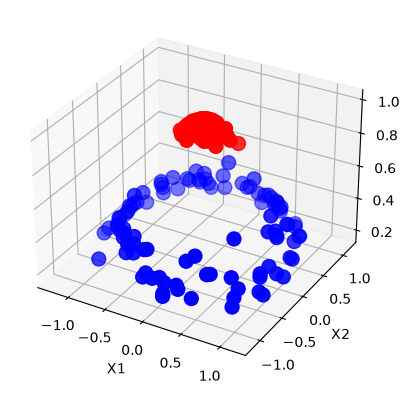

In [4]:
def plot_3d_plot(X, y, degree = 2):
    r = np.exp(-(X ** degree).sum(1))
    ax = plt.subplot(projection='3d')
    ax.scatter3D(X[:, 0], X[:, 1], r, c=y, s=100, cmap='bwr')
    ax.set_xlabel('X1')
    ax.set_ylabel('X2')
    ax.set_zlabel('y')
    return ax
plot_3d_plot(X,y)

In [5]:
X_train , X_test , y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 42)

1.0


<Axes3D: xlabel='X1', ylabel='X2', zlabel='y'>

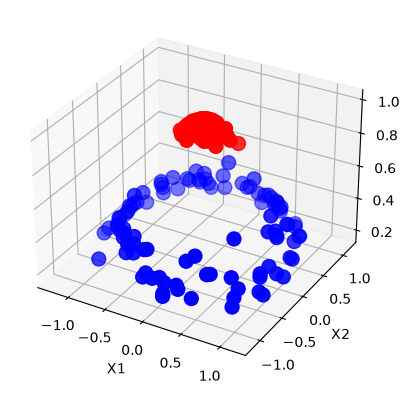

In [6]:
rbf_classifier = SVC(kernel= 'rbf')
rbf_classifier.fit(X_train,y_train)
y_pred = rbf_classifier.predict(X_test)
print(accuracy_score(y_test, y_pred))
plot_3d_plot(X,y)

0.575


<Axes3D: xlabel='X1', ylabel='X2', zlabel='y'>

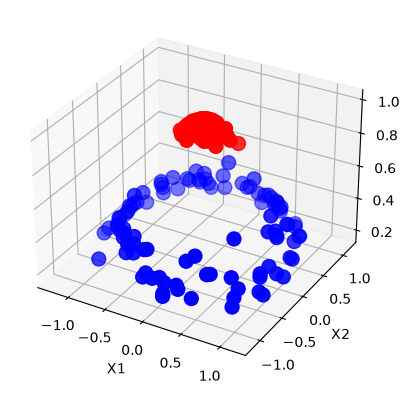

In [7]:
linear_classifier = SVC(kernel = 'linear')
linear_classifier.fit(X_train, y_train)
y_pred = linear_classifier.predict(X_test)
print(accuracy_score(y_test, y_pred))
plot_3d_plot(X,y)

0.575


<Axes3D: xlabel='X1', ylabel='X2', zlabel='y'>

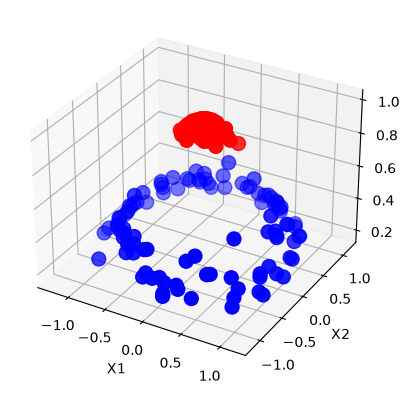

In [8]:
poly_classifier = SVC(kernel = 'linear')
poly_classifier.fit(X_train, y_train)
y_pred = poly_classifier.predict(X_test)
print(accuracy_score(y_test, y_pred))
plot_3d_plot(X,y)

0.725


<Axes3D: xlabel='X1', ylabel='X2', zlabel='y'>

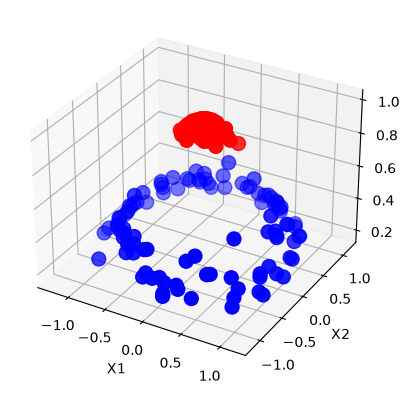

In [9]:
sigmoid_classifier = SVC(kernel = 'sigmoid')
sigmoid_classifier.fit(X_train , y_train)
y_pred = sigmoid_classifier.predict(X_test)
print(accuracy_score(y_test, y_pred))
plot_3d_plot(X,y)

In [10]:
def plot_3d_plot(X,y, degree = 2):
    r = np.exp((-(X**2)).sum(1))
    ax = plt.subplot(projection = '3d')
    ax.scatter3D(X[:,0],X[:,1],r, c= y , s= 100)
    ax.set_title('3D Plot')
    ax.set_xlabel('X1')
    return ax


1.0


<Axes3D: title={'center': '3D Plot'}, xlabel='X1'>

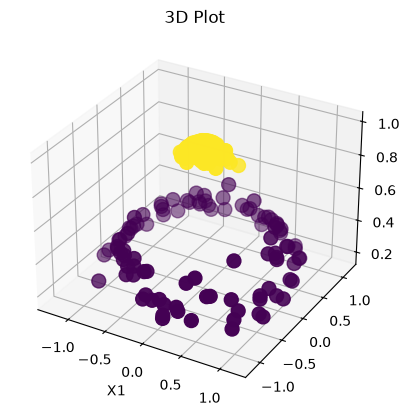

In [11]:
model = SVC(kernel= 'poly', degree = 2)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(accuracy_score(y_test, y_pred))
plot_3d_plot(X,y)

# Dataset 2 

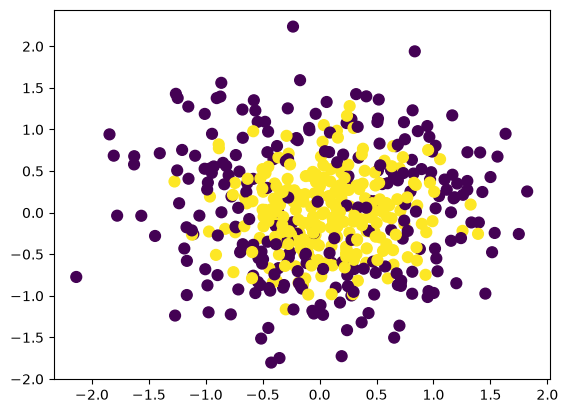

In [12]:
X, y = make_circles(n_samples= 500, factor = 0.3, noise = 0.4, random_state = 42,)
plt.scatter(X[:,0], X[:,1], c= y, s= 60)


In [13]:
from sklearn.model_selection import StratifiedShuffleSplit, train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_curve, confusion_matrix, classification_report
X_train, X_test , y_train, y_test = train_test_split(X,y, test_size= 0.2, random_state= 42)


model = DecisionTreeClassifier(max_depth = 10, min_samples_leaf = 5, min_samples_split = 12, ccp_alpha = 0.001, max_features = 5,random_state = 42)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print('Accuracy Score: ',accuracy_score(y_test , y_pred))
print('Training Score: ',model.score(X_train, y_train))
print('Testing Score: ',model.score(X_test, y_test))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test , y_pred))


Accuracy Score:  0.7
Training Score:  0.8375
Testing Score:  0.7
[[36  7]
 [23 34]]
              precision    recall  f1-score   support

           0       0.61      0.84      0.71        43
           1       0.83      0.60      0.69        57

    accuracy                           0.70       100
   macro avg       0.72      0.72      0.70       100
weighted avg       0.74      0.70      0.70       100



<Axes3D: title={'center': '3D Plot'}, xlabel='X1'>

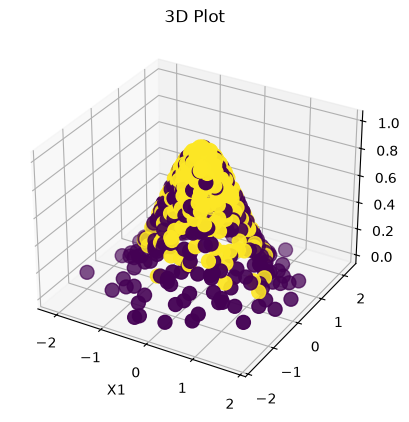

In [14]:
plot_3d_plot(X,y, degree = 8)

# Dataset 3

In [15]:
import pandas as pd
df = pd.read_csv(r"D:\scikit-learn.py\ml_projects.ipynb\customer_churn_cleaned_dataset.csv", encoding = 'latin-1')
X = np.array(df.drop(columns = ['Churn']))
y = np.array(df['Churn'])


In [16]:
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve

scaler = StandardScaler()
X_train, X_test , y_train, y_test = train_test_split(X,y,test_size= 0.2 , random_state= 42)

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

clf = SVC(kernel= 'rbf', C = 9, random_state= 42, gamma = 0.01,max_iter= 1000, shrinking= True,probability= True)
clf.fit(X_train_scaled,y_train)
y_pred = clf.predict_proba(X_test_scaled)[:,1]
fpr , tpr, thresholds = roc_curve(y_test, y_pred)
optimal_threshold = thresholds[np.argmax(tpr - fpr)]
y_pred =( y_pred >= optimal_threshold).astype(int)

print('Accuracy Score: ',accuracy_score(y_test, y_pred))
print('Training Score: ',clf.score(X_train_scaled, y_train))
print('Testing Score: ',clf.score(X_test_scaled, y_test))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test , y_pred))

d:\scikit-learn.py\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
d:\scikit-learn.py\.venv\Lib\site-packages\sklearn\svm\_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


Accuracy Score:  0.8725
Training Score:  0.925625
Testing Score:  0.906875
[[1271  136]
 [  68  125]]
              precision    recall  f1-score   support

           0       0.95      0.90      0.93      1407
           1       0.48      0.65      0.55       193

    accuracy                           0.87      1600
   macro avg       0.71      0.78      0.74      1600
weighted avg       0.89      0.87      0.88      1600



2
2
2


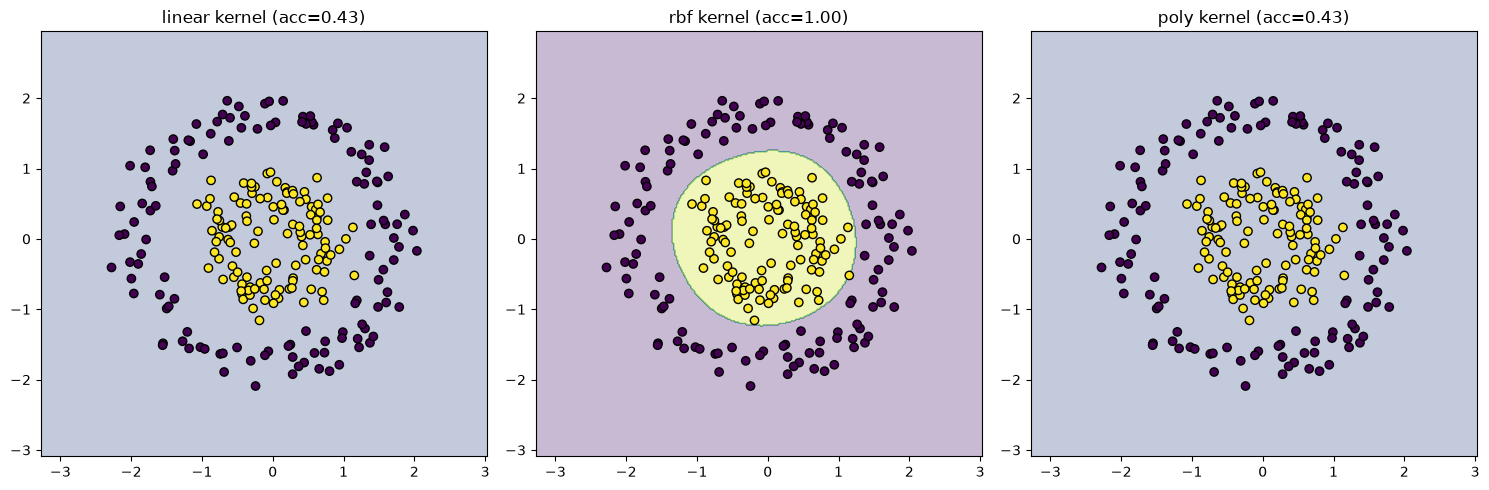

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles, make_moons
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Non-linear dataset generate karo
X, y = make_circles(n_samples=300, noise=0.1, factor=0.4, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling (SVM ke liye zaroori — abhi discuss kiya)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Teen kernels compare karo
kernels = ['linear', 'rbf', 'poly']
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, k in enumerate(kernels):
    model = SVC(kernel=k, gamma='scale', degree=3, C=1.0)
    model.fit(X_train_scaled, y_train)
    acc = model.score(X_test_scaled, y_test)
    
    # Decision boundary plot
    ax = axes[idx]
    x_min, x_max = X_train_scaled[:,0].min()-1, X_train_scaled[:,0].max()+1
    y_min, y_max = X_train_scaled[:,1].min()-1, X_train_scaled[:,1].max()+1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))
    xy = np.vstack([xx.ravel(), yy.ravel()]).T
    print(xx.ndim)
    Z = model.predict(xy).reshape(xx.shape)
 
    ax.contourf(xx, yy, Z, alpha=0.3)
    ax.scatter(X_train_scaled[:,0], X_train_scaled[:,1],c = y_train, edgecolors= 'k')
    ax.set_title(f'{k} kernel (acc={acc:.2f})')
    

plt.tight_layout()
plt.show()

In [29]:
from sklearn.svm import SVR
from sklearn.datasets import make_regression, make_friedman1
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.datasets import fetch_california_housing, load_diabetes

X, y = fetch_california_housing(return_X_y= True)
scaler = StandardScaler()
X_train,X_test, y_train , y_test = train_test_split(X,y , test_size= 0.2, random_state= 42)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


model = SVR(kernel = 'rbf')
model.fit(X_train_scaled,y_train)
y_pred = model.predict(X_test_scaled)
print(f'Kernel: {k}')
print('R2 score: ',r2_score(y_test,y_pred))
print('Training Score: ',model.score(X_train_scaled, y_train))
print('Testing Score: ',model.score(X_test_scaled,y_test))
print('MSE: ', mean_squared_error(y_test, y_pred))
print(f'MAE: ',mean_absolute_error(y_test,y_pred))
print('RMSE: ', root_mean_squared_error(y_test, y_pred))
print('-'* 50)



Kernel: poly
R2 score:  0.7275639524733043
Training Score:  0.7485520410535171
Testing Score:  0.7275639524733043
MSE:  0.3570026426754465
MAE:  0.3985982830145758
RMSE:  0.5974969813107398
--------------------------------------------------


In [30]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
model = DecisionTreeRegressor()

model.fit(X_train_scaled,y_train)

y_pred = model.predict(X_test_scaled)
print('R2 score: ',r2_score(y_test,y_pred))
print('MSE: ', mean_squared_error(y_test, y_pred))
print(f'MAE: ',mean_absolute_error(y_test,y_pred))
print('RMSE: ', root_mean_squared_error(y_test, y_pred))
print('-'* 50)

R2 score:  0.616834428184725
MSE:  0.5021036054595446
MAE:  0.4555646075581396
RMSE:  0.7085926936255725
--------------------------------------------------


In [31]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor()
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)
print('R2 score: ',r2_score(y_test,y_pred))
print('MSE: ', mean_squared_error(y_test, y_pred))
print(f'MAE: ',mean_absolute_error(y_test,y_pred))
print('RMSE: ', root_mean_squared_error(y_test, y_pred))
print('-'* 50)


R2 score:  0.8073095719512723
MSE:  0.25250326693613484
MAE:  0.3257841291182172
RMSE:  0.502497031768482
--------------------------------------------------


In [70]:
from sklearn.datasets import fetch_california_housing
from sklearn.neighbors import KNeighborsRegressor
X, y = fetch_california_housing(return_X_y= True)
scaler = StandardScaler()
X_train,X_test, y_train , y_test = train_test_split(X,y , test_size= 0.2, random_state= 42)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


reg = KNeighborsRegressor(n_neighbors= 13)
reg.fit(X_train_scaled,y_train)
y_pred = reg.predict(X_test_scaled)
print(f'K = {13}',r2_score(y_test,y_pred))
print('Training Score: ',model.score(X_train_scaled, y_train))
print('Testing Score: ',model.score(X_test_scaled,y_test))
print('MSE: ', mean_squared_error(y_test, y_pred))
print(f'MAE: ',mean_absolute_error(y_test,y_pred))
print('RMSE: ', root_mean_squared_error(y_test, y_pred))
print('-'* 50)
   

K = 13 0.6823213122898445
Training Score:  0.9740877038050233
Testing Score:  0.8073095719512723
MSE:  0.41628900457117474
MAE:  0.4373025245974955
RMSE:  0.6452046222487675
--------------------------------------------------
